# Weighted turbine power

Pass `turbine_power` to `WindFarmNetwork` when turbines have different nominal power. Cable capacities and turbine powers must use the same units.

> Weighted power requires `MILPRouter`. Use `feeder_limit='unlimited'` (the default), `'exactly'`, or `'specified'`.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

from optiwindnet.api import MILPRouter, WindFarmNetwork

## Inputs

In [12]:
turbinesC = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.4],
        [2.0, 0.0],
        [0.3, 1.2],
        [1.3, 1.6],
        [2.4, 1.1],
    ]
)
substationsC = np.array([[1.2, -1.0]])
borderC = np.array([[-0.5, -1.5], [3.0, -1.5], [3.0, 2.1], [-0.5, 2.1]])

# Cable capacities and turbine power use the same nominal units.
cables = [(2, 1.0), (3, 1.3), (4, 1.6)]
turbine_power = [1.0, 1.25, 1.0, 1.25, 1.5, 1.75]

router = MILPRouter('ortools.cp_sat', time_limit=5, mip_gap=0.01)
network_inputs = dict(
    cables=cables,
    turbinesC=turbinesC,
    substationsC=substationsC,
    borderC=borderC,
    router=router,
)

## Weighted network

The first case preserves two decimal places.

In [13]:
weighted_2d = WindFarmNetwork(
    **network_inputs,
    turbine_power=turbine_power,
    turbine_power_decimals=2,
)
weighted_2d.optimize()

print('Power:', weighted_2d.turbine_power)
print('Scale:', weighted_2d.power_scale)

Power: [1.0, 1.25, 1.0, 1.25, 1.5, 1.75]
Scale: 4


## Decimal precision

`turbine_power_decimals` controls rounding before OptiWindNet converts nominal powers to the smallest equivalent integer scale. With one decimal place, `1.25` becomes `1.3`, so both the rounded powers and scale change.

In [14]:
weighted_1d = WindFarmNetwork(
    **network_inputs,
    turbine_power=turbine_power,
    turbine_power_decimals=1,
)
weighted_1d.optimize()

print('Power:', weighted_1d.turbine_power)
print('Scale:', weighted_1d.power_scale)

Power: [1.0, 1.3, 1.0, 1.3, 1.5, 1.8]
Scale: 10


## Compare with uniform power

The uniform case uses the same layout, cables, and solver but omits `turbine_power`.

In [15]:
uniform = WindFarmNetwork(**network_inputs)
uniform.optimize()

print('Power:', uniform.turbine_power)
print('Scale:', uniform.power_scale)

Power: None
Scale: 1


Visualize 3 networks side by side:


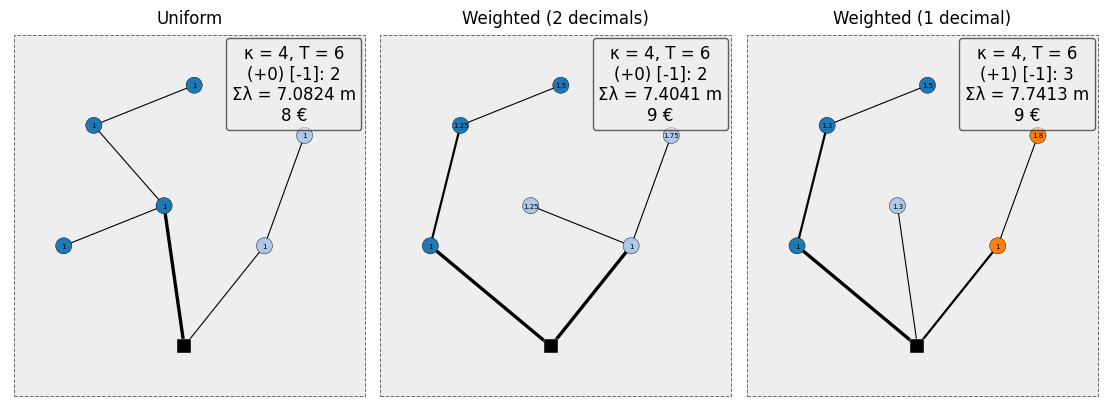

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(11, 5), constrained_layout=True)

for ax, title, network in zip(
    axes,
    ('Uniform', 'Weighted (2 decimals)', 'Weighted (1 decimal)'),
    (uniform, weighted_2d, weighted_1d),
):
    network.plot(ax=ax, node_tag='power')
    ax.set_title(title)

print("Visualize 3 networks side by side:")
plt.show()